In [ ]:
import pandas as pd
from collections import Counter



In [ ]:
df = pd.read_csv('/content/IMDB Dataset.csv' )



In [ ]:
# Converting everything to lower case
df['review'] = df['review'].str.lower()

# Replacing html line braks with space
df['review'] = df['review'].str.replace('<br />', ' ', regex=False)

# 3. Removing ALL punctuation marks
df['review'] = df['review'].str.replace(r'[^\w\s]', '', regex=True)

# 4. Print the first 5 rows of JUST the review column so we can inspect it closely
print(df['review'].iloc[4])

petter matteis love in the time of money is a visually stunning film to watch mr mattei offers us a vivid portrait about human relations this is a movie that seems to be telling us what money power and success do to people in the different situations we encounter   this being a variation on the arthur schnitzlers play about the same theme the director transfers the action to the present time new york where all these different characters meet and connect each one is connected in one way or another to the next person but no one seems to know the previous point of contact stylishly the film has a sophisticated luxurious look we are taken to see how these people live and the world they live in their own habitat  the only thing one gets out of all these souls in the picture is the different stages of loneliness each one inhabits a big city is not exactly the best place in which human relations find sincere fulfillment as one discerns is the case with most of the people we encounter  the act

In [ ]:

# 1. We take all the positive reviews and glue them together into one giant paragraph
positive_df = df[df['sentiment'] == 'positive']
all_positive_text = " ".join(positive_df['review'])

# 2. We chop that giant paragraph into a list of individual words
all_positive_words = all_positive_text.split()

# 3. We create a list of "boring" words to ignore
boring_words = {'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that',
                'was', 'as', 'for', 'with', 'movie', 'film', 'on', 'but', 'are', 'not',
                'you', 'his', 'have', 'be', 'one', 'he', 'all', 'at', 'by', 'an', 'they',
                'who', 'so', 'from', 'like', 'there', 'her', 'or', 'just', 'about', 'out',
                'has', 'if', 'what', 'some', 'good'}

# 4. We loop through all the words, and only keep the meaningful ones!
meaningful_words = [word for word in all_positive_words if word not in boring_words]

# 5. We use Python's built-in Counter to find the most common ones!
word_counts = Counter(meaningful_words)

print("Top 10 most frequent words in POSITIVE reviews:")
# .most_common(10) prints the top 10 words and their exact counts
for word, count in word_counts.most_common(10):
    print(f"{word}: {count} times")

Top 10 most frequent words in POSITIVE reviews:
its: 25525 times
very: 16101 times
more: 14669 times
when: 14474 times
she: 12942 times
my: 12836 times
great: 12810 times
story: 12609 times
their: 12235 times
time: 12122 times


In [ ]:
"""
We are finding the total number of occurring words in the positive reviews
so that we can find their probabilities
"""
# We put our 4 chosen words into a list!
words_to_check = ['superb', 'wonderful', 'excellent', 'fantastic']

# Find the total Reviews
total_reviews = len(df)

# SEPARATING POSITIVE REVIEWS FROM OTHER REVIEWS
positive_df = df[df['sentiment'] == 'positive']
total_positive_reviews = len(positive_df)

print(f"Total reviews: {total_reviews}")
print(f"Total Positive reviews: {total_positive_reviews}\n")

# Now we loop through each word and apply your exact counting logic!
for word in words_to_check:

    # COUNTING THE WORD IN ALL REVIEWS:
    reviews_with_word = df['review'].str.contains(rf'\b{word}\b')
    word_total_count = reviews_with_word.sum()

    # COUNTING THE WORD IN ONLY POSITIVE REVIEWS:
    positive_reviews_with_word = positive_df['review'].str.contains(rf'\b{word}\b')
    word_in_positive_count = positive_reviews_with_word.sum()

    print(f"--- '{word.upper()}' ---")
    print(f"Total counts in all dataset: {word_total_count}")
    print(f"Total counts in Positive reviews: {word_in_positive_count}\n")

Total reviews: 50000
Total Positive reviews: 25000

--- 'SUPERB' ---
Total counts in all dataset: 1188
Total counts in Positive reviews: 1015

--- 'WONDERFUL' ---
Total counts in all dataset: 2756
Total counts in Positive reviews: 2235

--- 'EXCELLENT' ---
Total counts in all dataset: 3525
Total counts in Positive reviews: 2846

--- 'FANTASTIC' ---
Total counts in all dataset: 1322
Total counts in Positive reviews: 1056



In [ ]:

# Creating function for to calculate marginal and posterior
def calculate_bayes_posterior(word, total_reviews, pos_df, total_pos_revs, prior):

    # Get counts
    word_total_count = df['review'].str.contains(rf'\b{word}\b').sum()
    word_in_positive_count= pos_df['review'].str.contains(rf'\b{word}\b').sum()

    # Calculate probabilities
    marginal =word_total_count / total_reviews
    likelihood = word_in_positive_count / total_positive_reviews

    # Bayes Theorem (Avoid dividing by zero)
    if marginal == 0:
        return 0, 0, 0
    posterior = (likelihood * prior) / marginal

    return likelihood, marginal, posterior

# --- 2. CALCULATING THE PRIOR ---
prior_prob = total_positive_reviews / total_reviews
print(f"Prior Probability P(Positive) = {prior_prob*100:.2f}%\n")

words_to_check = ['superb', 'wonderful', 'excellent', 'fantastic']


for word in words_to_check:
    # We call our function here to calcuate probabilities for every word
    likelihood_prob, marginal_prob, posterior_prob = calculate_bayes_posterior(
        word, total_reviews, positive_df, total_positive_reviews, prior_prob
    )

    print(f"--- '{word.upper()}' ---")
    print(f"Prior:      {prior_prob*100:.2f}%")
    print(f"Marginal:   {marginal_prob*100:.2f}%")
    print(f"Likelihood: {likelihood_prob*100:.2f}%")
    print(f"Posterior:  {posterior_prob*100:.2f}%\n")

Prior Probability P(Positive) = 50.00%

--- 'SUPERB' ---
Prior:      50.00%
Marginal:   2.38%
Likelihood: 4.06%
Posterior:  85.44%

--- 'WONDERFUL' ---
Prior:      50.00%
Marginal:   5.51%
Likelihood: 8.94%
Posterior:  81.10%

--- 'EXCELLENT' ---
Prior:      50.00%
Marginal:   7.05%
Likelihood: 11.38%
Posterior:  80.74%

--- 'FANTASTIC' ---
Prior:      50.00%
Marginal:   2.64%
Likelihood: 4.22%
Posterior:  79.88%



|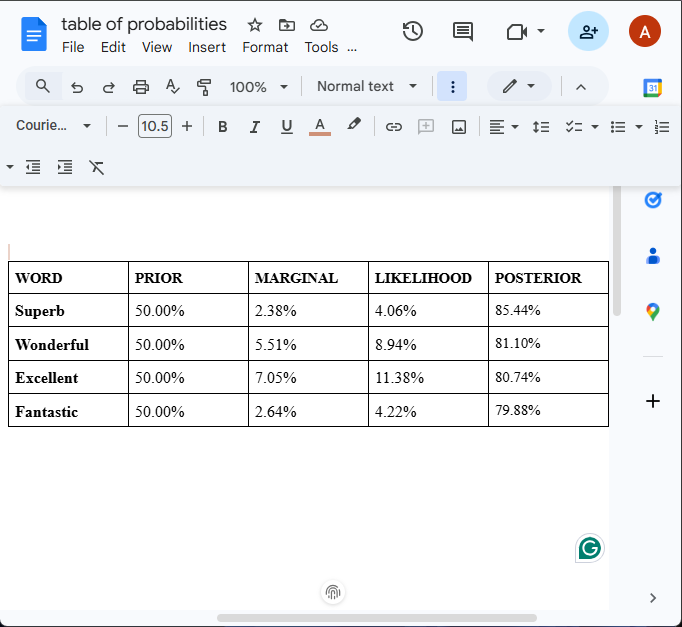
